# Étape 1 : Exploration des Données (EDA)
## Objectif : Comprendre la structure du dataset, visualiser les distributions et mesurer le déséquilibre de classes

In [3]:
# ============================================
# 1.1 — Imports et chargement des données
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
plt.style.use('ggplot')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)

# Chargement du dataset
df = pd.read_csv('../data/creditcard.csv')

# Premier aperçu
print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nTypes des colonnes :")
print(df.dtypes.value_counts())
print(f"\nAperçu des 5 premières lignes :")
df.head()

Dimensions du dataset : 284807 lignes × 31 colonnes

Types des colonnes :
float64    30
int64       1
Name: count, dtype: int64

Aperçu des 5 premières lignes :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1.2 — Statistiques descriptives et qualité des données

In [6]:
# ============================================
# 1.2 — Statistiques descriptives
# ============================================

# Vérification des valeurs manquantes
print("=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Aucune valeur manquante dans le dataset !")
else:
    print(missing[missing > 0])

# Vérification des doublons
duplicates = df.duplicated().sum()
print(f"\n=== DOUBLONS ===")
print(f"Nombre de lignes dupliquées : {duplicates}")

# Statistiques descriptives sur les colonnes non-PCA
print(f"\n=== STATISTIQUES SUR AMOUNT ===")
print(df['Amount'].describe())

print(f"\n=== STATISTIQUES SUR TIME ===")
print(df['Time'].describe())

# Distribution de la variable cible
print(f"\n=== DISTRIBUTION DE LA CIBLE (Class) ===")
print(df['Class'].value_counts())
print(f"\nPourcentage de fraudes : {df['Class'].mean() * 100:.3f}%")

=== VALEURS MANQUANTES ===
Aucune valeur manquante dans le dataset !

=== DOUBLONS ===
Nombre de lignes dupliquées : 1081

=== STATISTIQUES SUR AMOUNT ===
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

=== STATISTIQUES SUR TIME ===
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

=== DISTRIBUTION DE LA CIBLE (Class) ===
Class
0    284315
1       492
Name: count, dtype: int64

Pourcentage de fraudes : 0.173%


Valeurs manquantes — zéro, pas de nettoyage à faire sur ce point.  

Doublons — 1081 lignes dupliquées. C'est une question importante : est-ce que deux personnes peuvent faire exactement la même transaction (même montant, même moment) ?  

Amount — la moyenne est à 88€ mais la médiane à 22€. Ça veut dire que la distribution est très asymétrique vers la droite : beaucoup de petites transactions et quelques très grosses (max 25 691€).  

Class — 284 315 légitimes vs 492 fraudes, soit 0.173%. C'est un déséquilibre extrême. Si un modèle prédit "pas fraude" à chaque fois, il a 99.83% d'accuracy mais ne détecte aucune fraude. C'est pour ça que l'accuracy sera une métrique inutile.

## 1.3 — Visualisation du déséquilibre de classes

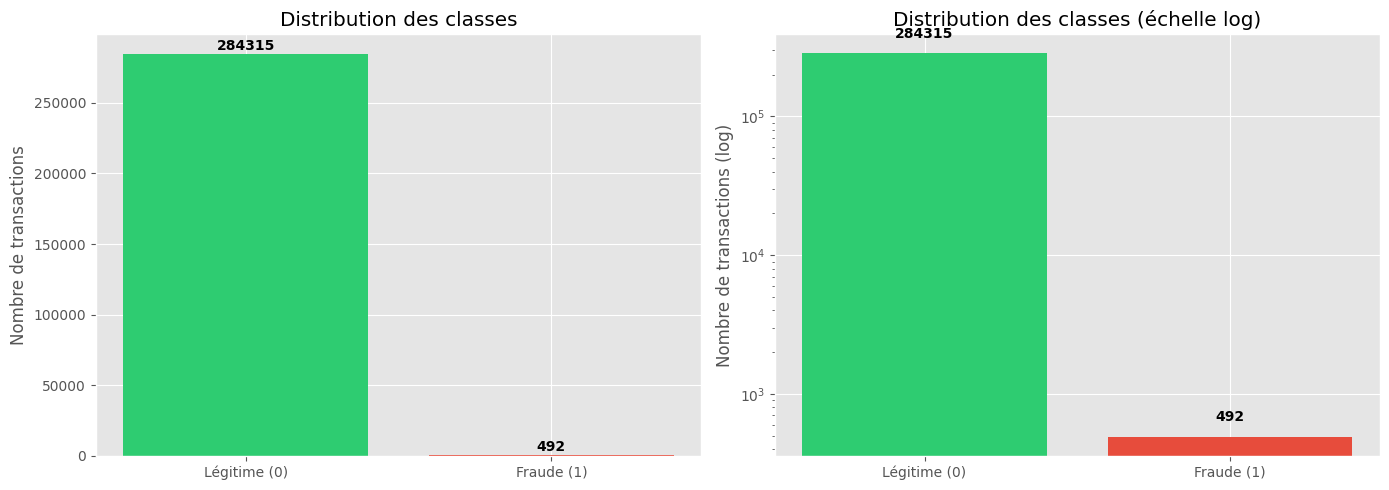

Ratio déséquilibre : 1 fraude pour 577 transactions légitimes


In [7]:
# ============================================
# 1.3 — Visualisation du déséquilibre de classes
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Barplot des effectifs
counts = df['Class'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Légitime (0)', 'Fraude (1)'])
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_title('Distribution des classes')
# Ajouter les valeurs sur les barres
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3000, str(v), ha='center', fontweight='bold')

# Graphique 2 : Même chose en échelle log pour mieux voir
axes[1].bar(counts.index, counts.values, color=colors)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Légitime (0)', 'Fraude (1)'])
axes[1].set_ylabel('Nombre de transactions (log)')
axes[1].set_yscale('log')
axes[1].set_title('Distribution des classes (échelle log)')
for i, v in enumerate(counts.values):
    axes[1].text(i, v * 1.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ratio déséquilibre : 1 fraude pour {counts[0]//counts[1]} transactions légitimes")

Il y a énormément de de transaction légitime pour très peu de fraude.

## 1.4 — Analyse des features discriminantes

Les colonnes V1-V28 sont issues d'une PCA et ne sont pas interprétables métier. 
Pour comprendre lesquelles distinguent le mieux les fraudes des transactions légitimes, 
on compare la différence de moyenne entre les deux classes.

On visualise ici les 6 features présentant la plus grande séparation. 
Cela ne constitue pas une sélection de features — toutes seront conservées 
pour la modélisation. L'objectif est purement exploratoire : identifier 
visuellement quelles features le modèle pourra exploiter.

Top 6 features les plus discriminantes :
['Time', 'Amount', 'V3', 'V14', 'V17', 'V12']



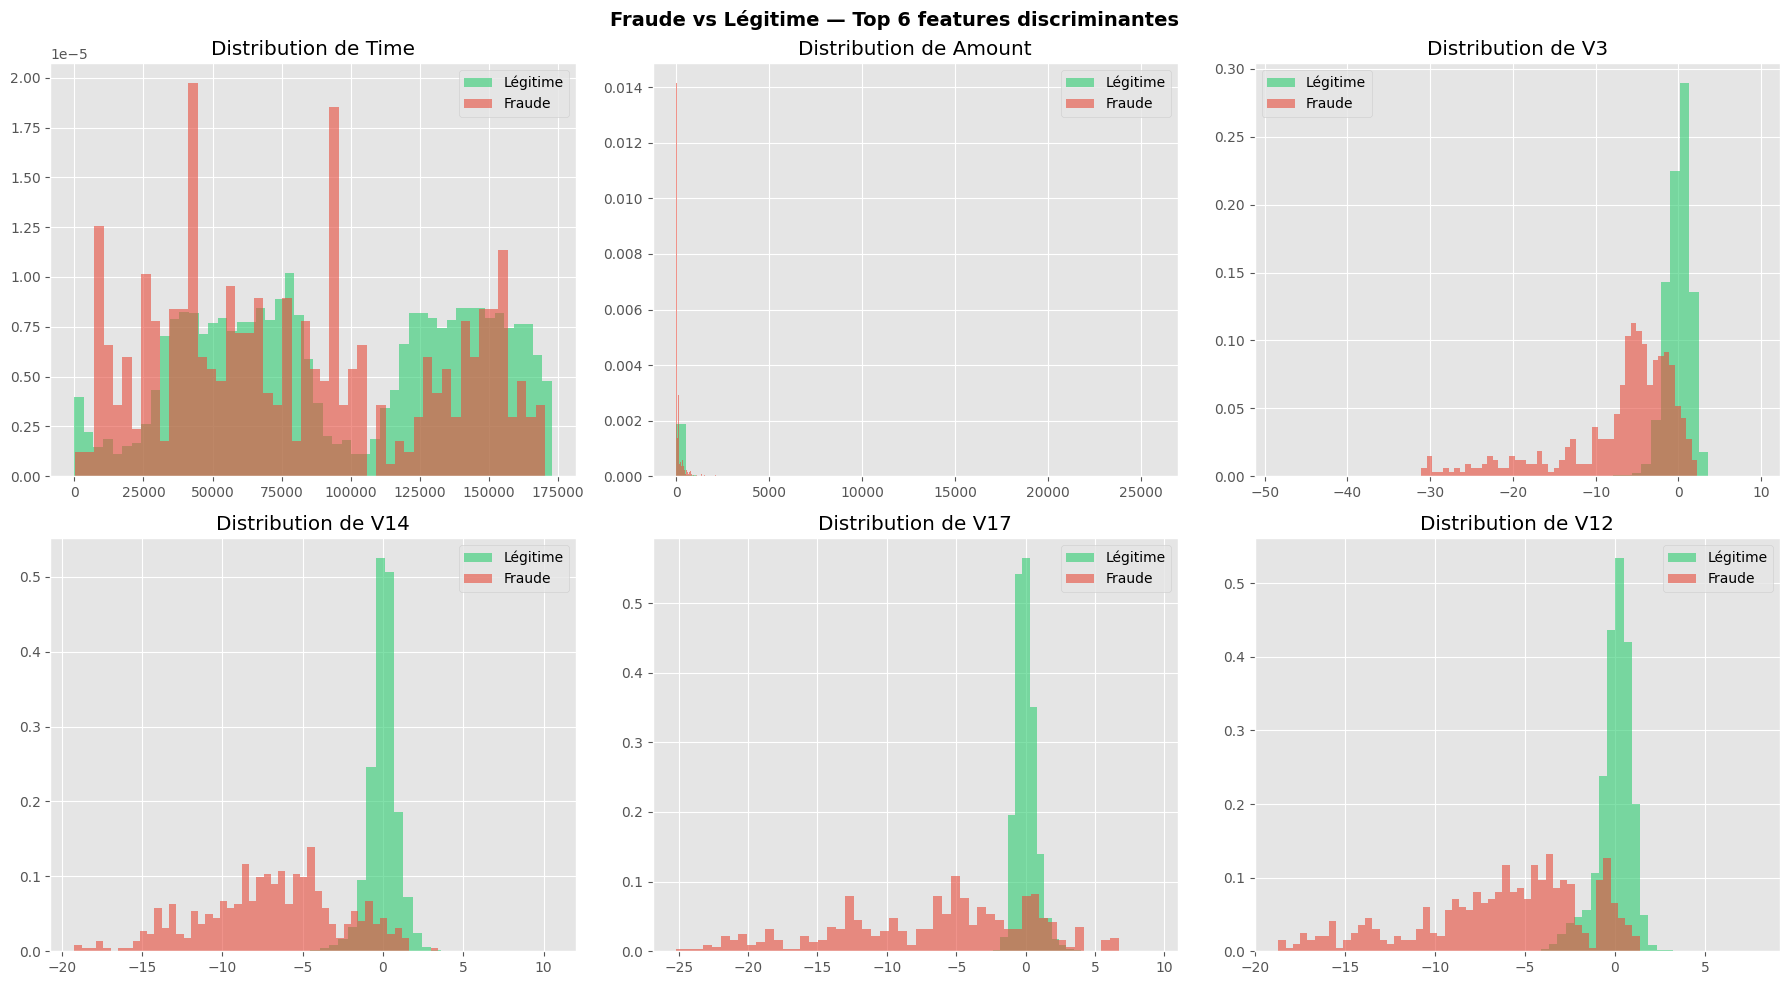

In [8]:
# ============================================
# 1.4 — Comparaison des distributions Fraude vs Légitime
# ============================================

# On sélectionne les features V les plus discriminantes
# Pour ça, on compare la moyenne de chaque feature entre les 2 classes
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

# Calcul de la différence de moyenne pour chaque feature
mean_diff = (fraud.mean() - legit.mean()).abs().sort_values(ascending=False)
top_features = mean_diff.head(8).index.tolist()
# On retire 'Class' si elle apparaît
top_features = [f for f in top_features if f != 'Class'][:6]

print(f"Top 6 features les plus discriminantes :\n{top_features}\n")

# Visualisation : distribution de ces features pour Fraude vs Légitime
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].hist(legit[feature], bins=50, alpha=0.6, label='Légitime', color='#2ecc71', density=True)
    axes[i].hist(fraud[feature], bins=50, alpha=0.6, label='Fraude', color='#e74c3c', density=True)
    axes[i].set_title(f'Distribution de {feature}')
    axes[i].legend()

plt.suptitle('Fraude vs Légitime — Top 6 features discriminantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/top_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

On observe que V3, V14, V17 et V12 séparent bien les fraudes des transactions 
légitimes (peu de chevauchement entre les distributions).

Time et Amount montrent un fort chevauchement entre les deux classes, ce qui 
suggère qu'elles sont moins discriminantes sous leur forme brute. Elles seront 
transformées à l'étape de feature engineering pour potentiellement améliorer 
leur pouvoir prédictif.

## 1.5 — Matrice de corrélation avec la variable cible

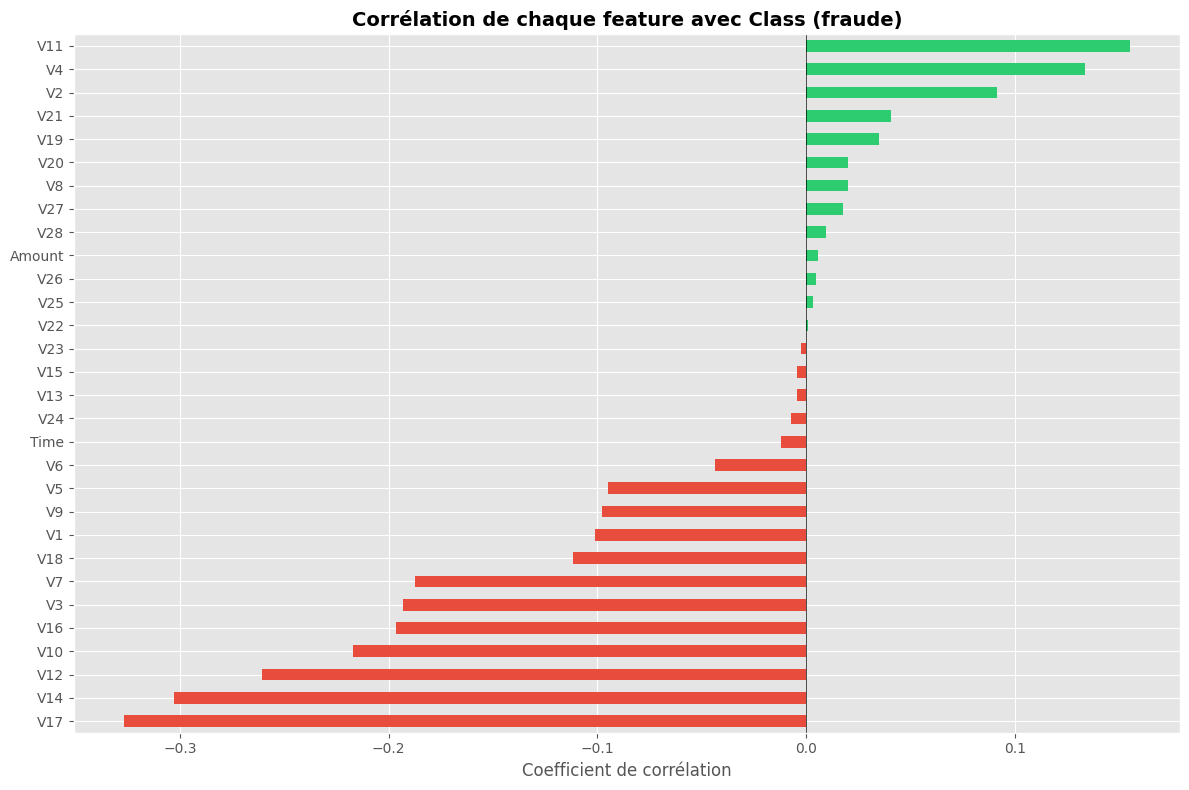

=== TOP CORRÉLATIONS NÉGATIVES (fraude quand la valeur baisse) ===
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

=== TOP CORRÉLATIONS POSITIVES (fraude quand la valeur monte) ===
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


In [9]:
# ============================================
# 1.5 — Corrélation des features avec Class
# ============================================

# On calcule la corrélation de chaque feature avec la cible
correlations = df.corr()['Class'].drop('Class').sort_values()

# Visualisation
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in correlations]
correlations.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Corrélation de chaque feature avec Class (fraude)', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient de corrélation')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../outputs/correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features les plus corrélées (positivement et négativement)
print("=== TOP CORRÉLATIONS NÉGATIVES (fraude quand la valeur baisse) ===")
print(correlations.head(5))
print(f"\n=== TOP CORRÉLATIONS POSITIVES (fraude quand la valeur monte) ===")
print(correlations.tail(5))

### Analyse de la corrélation

La corrélation mesure la relation linéaire entre chaque feature et la variable cible (Class).

- **Plus une corrélation est loin de 0** (positive ou négative), plus la feature 
  a un lien fort avec la fraude.
- **Corrélation positive** (ex: V11 = +0.15) : plus la valeur augmente, plus la 
  probabilité de fraude augmente.
- **Corrélation négative** (ex: V17 = -0.33) : plus la valeur diminue, plus la 
  probabilité de fraude augmente.
- **Corrélation proche de 0** (ex: Time = -0.01) : pas de relation linéaire 
  significative avec la fraude.

Les features les plus corrélées (V14, V17, V12, V10) confirment les observations 
de la section 1.4 sur les distributions.